In [ ]:
from module import *
import statsmodels.tsa.stattools as smt

def plot_stl(series, period=24, title="STL"):
    stl = STL(series.rename(title), period=period)
    res = stl.fit()
    fig = res.plot()
    plt.xticks(rotation=45)
    plt.show()

# Calories, Intensity & Steps

## Table Info

In [ ]:
table_info("hourly_calories")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5 non-null      float64
 1   ActivityHour  5 non-null      str    
 2   Calories      5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,Id,ActivityHour,Calories
0,1.503960e+09,3/12/2016 12:00:00 AM,48
1,1.503960e+09,3/12/2016 1:00:00 AM,48
2,1.503960e+09,3/12/2016 2:00:00 AM,48
3,1.503960e+09,3/12/2016 3:00:00 AM,48
4,1.503960e+09,3/12/2016 4:00:00 AM,48


In [ ]:
table_info("hourly_intensity")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                5 non-null      float64
 1   ActivityHour      5 non-null      str    
 2   TotalIntensity    5 non-null      int64  
 3   AverageIntensity  5 non-null      float64
dtypes: float64(2), int64(1), str(1)
memory usage: 292.0 bytes


,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1.503960e+09,3/12/2016 12:00:00 AM,0,0.0
1,1.503960e+09,3/12/2016 1:00:00 AM,0,0.0
2,1.503960e+09,3/12/2016 2:00:00 AM,0,0.0
3,1.503960e+09,3/12/2016 3:00:00 AM,0,0.0
4,1.503960e+09,3/12/2016 4:00:00 AM,0,0.0


In [ ]:
pd.read_sql("""
            SELECT TotalIntensity / AverageIntensity
            FROM hourly_intensity
            """, conn).describe()

,TotalIntensity / AverageIntensity
count,13038.000000
mean,59.999929
std,0.000377
min,59.998800
25%,59.999937
50%,60.000000
75%,60.000046
max,60.000600


AverageIntensity = TotalIntensity per minute

In [ ]:
table_info("hourly_steps")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5 non-null      float64
 1   ActivityHour  5 non-null      str    
 2   StepTotal     5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,Id,ActivityHour,StepTotal
0,1.503960e+09,3/12/2016 12:00:00 AM,0
1,1.503960e+09,3/12/2016 1:00:00 AM,0
2,1.503960e+09,3/12/2016 2:00:00 AM,0
3,1.503960e+09,3/12/2016 3:00:00 AM,0
4,1.503960e+09,3/12/2016 4:00:00 AM,0


## Data

In [14]:
cis_df = pd.read_sql("""
                 SELECT *
                 FROM hourly_calories
                 NATURAL JOIN hourly_intensity
                 NATURAL JOIN hourly_steps
                 """, conn)
cis_df['Id'] = cis_df['Id'].astype(int).astype(str)
cis_df['Time'] = pd.to_datetime(cis_df['ActivityHour'], format=DATE_FMT)
cis_df = cis_df.set_index(['Id', 'Time'])\
    .drop(columns=['ActivityHour','AverageIntensity'])
cis_stats = cis_df.reset_index().groupby('Time').describe()
cis_stats

Calories                                              \
                       count        mean         std   min    25%    50%   
Time                                                                       
2016-03-12 00:00:00     33.0   72.757576   20.029713  42.0  60.00   70.0   
2016-03-12 01:00:00     33.0   69.818182   16.407800  42.0  59.00   65.0   
2016-03-12 02:00:00     33.0   69.333333   16.838696  42.0  56.00   65.0   
2016-03-12 03:00:00     33.0   68.000000   15.132746  42.0  56.00   65.0   
2016-03-12 04:00:00     33.0   67.909091   15.593195  42.0  56.00   65.0   
...                      ...         ...         ...   ...    ...    ...   
2016-04-12 06:00:00     17.0   77.529412   27.466156  50.0  59.00   70.0   
2016-04-12 07:00:00     15.0  116.800000   62.061260  50.0  75.50   95.0   
2016-04-12 08:00:00     12.0   94.833333   49.198731  51.0  74.50   79.5   
2016-04-12 09:00:00     11.0   93.818182   34.472651  68.0  72.00   85.0   
2016-04-12 10:00:00      4.0  165.750000  139.042859  68.0  80.75  113.0   

                                   TotalIntensity             ...         \
                        75%    max          count       mean  ...    75%   
Time                                                          ...          
2016-03-12 00:00:00   83.00  147.0           33.0   2.969697  ...   1.00   
2016-03-12 01:00:00   83.00  105.0           33.0   1.424242  ...   2.00   
2016-03-12 02:00:00   80.00  113.0           33.0   0.878788  ...   0.00   
2016-03-12 03:00:00   78.00  107.0           33.0   0.515152  ...   0.00   
2016-03-12 04:00:00   77.00  108.0           33.0   0.484848  ...   0.00   
...                     ...    ...            ...        ...  ...    ...   
2016-04-12 06:00:00   82.00  154.0           17.0   5.647059  ...   7.00   
2016-04-12 07:00:00  146.50  292.0           15.0  22.266667  ...  28.00   
2016-04-12 08:00:00   90.75  236.0           12.0  11.000000  ...  13.25   
2016-04-12 09:00:00  101.00  186.0           11.0  15.727273  ...  16.00   
2016-04-12 10:00:00  198.00  369.0            4.0  51.750000  ...  80.75   

                           StepTotal                                         \
                       max     count         mean          std  min     25%   
Time                                                                          
2016-03-12 00:00:00   34.0      33.0    37.000000    81.428650  0.0    0.00   
2016-03-12 01:00:00   12.0      33.0    22.000000    50.947277  0.0    0.00   
2016-03-12 02:00:00   10.0      33.0    12.393939    41.411758  0.0    0.00   
2016-03-12 03:00:00   11.0      33.0     4.393939    17.781555  0.0    0.00   
2016-03-12 04:00:00   11.0      33.0     5.636364    22.368809  0.0    0.00   
...                    ...       ...          ...          ...  ...     ...   
2016-04-12 06:00:00   28.0      17.0   127.705882   228.197219  0.0    0.00   
2016-04-12 07:00:00  109.0      15.0   684.533333  1029.359084  0.0   36.50   
2016-04-12 08:00:00   48.0      12.0   307.333333   452.643414  0.0    9.75   
2016-04-12 09:00:00   76.0      11.0   492.272727   837.835198  0.0    0.00   
2016-04-12 10:00:00  143.0       4.0  2695.500000  3019.033455  0.0  123.00   

                                              
                        50%      75%     max  
Time                                          
2016-03-12 00:00:00     0.0    16.00   307.0  
2016-03-12 01:00:00     0.0    10.00   208.0  
2016-03-12 02:00:00     0.0     0.00   207.0  
2016-03-12 03:00:00     0.0     0.00   100.0  
2016-03-12 04:00:00     0.0     0.00   117.0  
...                     ...      ...     ...  
2016-04-12 06:00:00     0.0   209.00   881.0  
2016-04-12 07:00:00   412.0   791.00  3855.0  
2016-04-12 08:00:00   155.0   365.75  1513.0  
2016-04-12 09:00:00   230.0   492.00  2812.0  
2016-04-12 10:00:00  2703.5  5276.00  5375.0  

[755 rows x 24 columns]

## Stat Plots

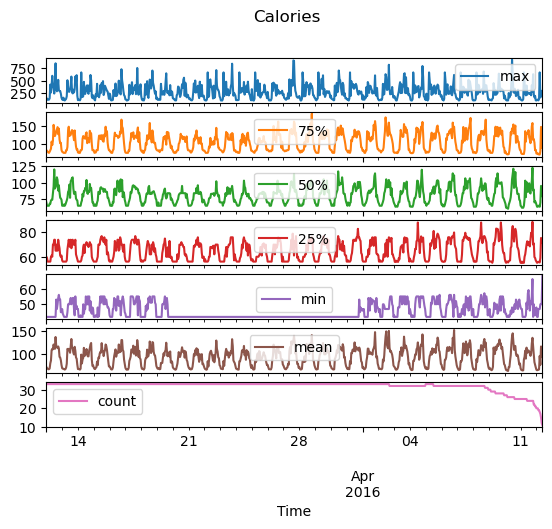

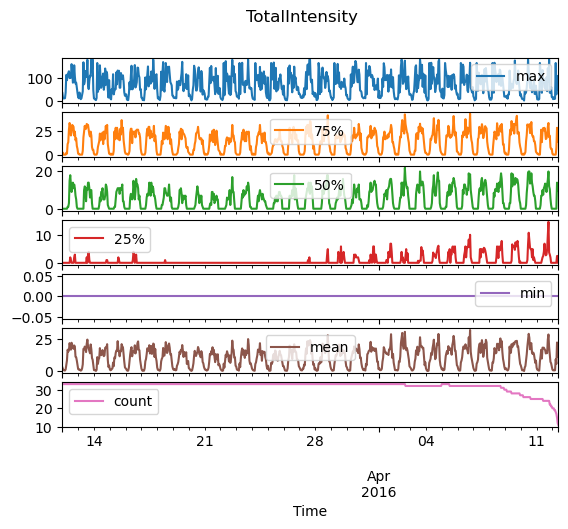

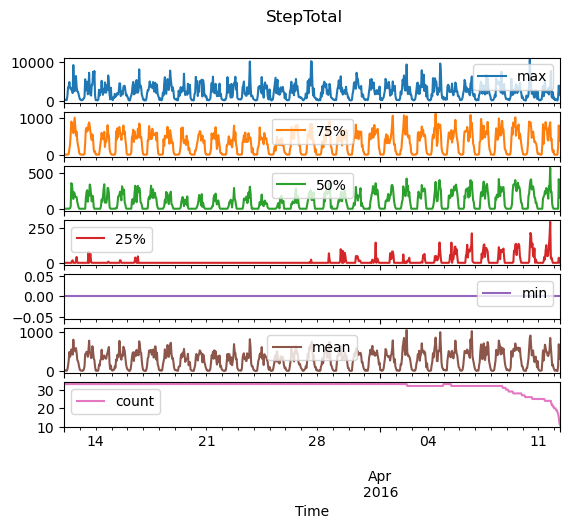

In [ ]:
for var in cis_df:
    stats = cis_stats[var].drop(columns=['std'])
    stats.loc[:,::-1].iloc[:-1].plot(subplots=True, sharex=True)
    plt.suptitle(f"{var}")
    plt.show()

## Correlations

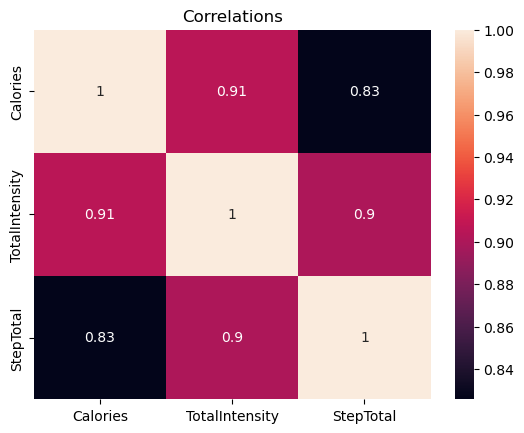

In [6]:
sns.heatmap(cis_df.corr(), annot=True)
plt.title("Correlations")
plt.show()

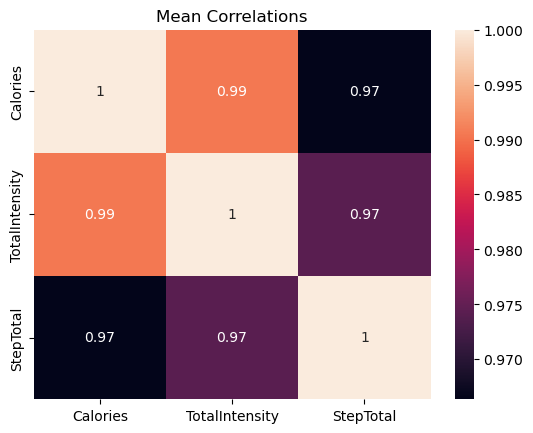

In [18]:
cis_means = cis_df.groupby('Time').mean().iloc[:-1]
sns.heatmap(cis_means.corr(), annot=True)
plt.title("Mean Correlations")
plt.show()

## OLS

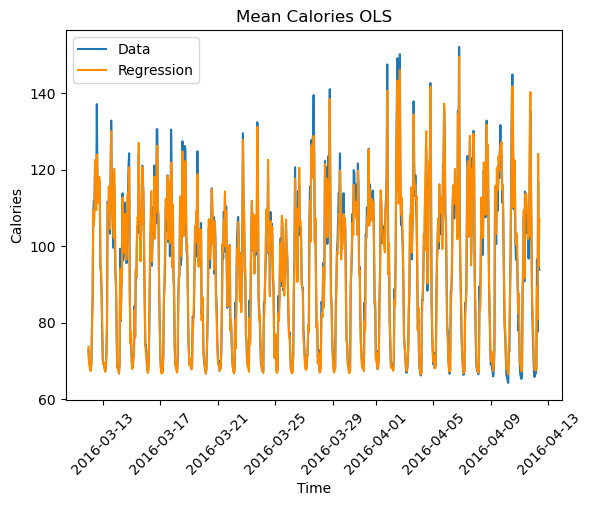

                            OLS Regression Results                            
Dep. Variable:               Calories   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 1.936e+04
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:14:31   Log-Likelihood:                -1816.0
No. Observations:                 754   AIC:                             3638.
Df Residuals:                     751   BIC:                             3652.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             66.1057      0.183    361.

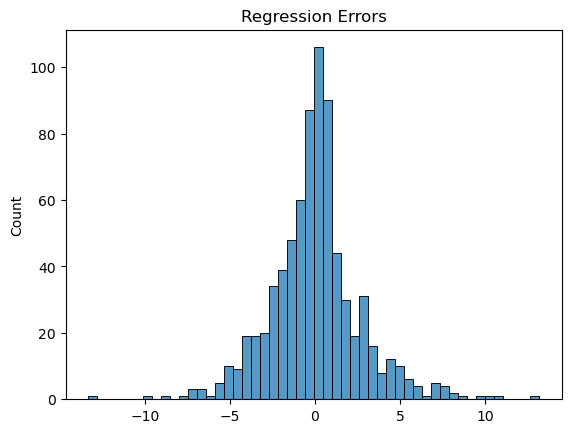

In [12]:
y = cis_means['Calories']
X = cis_means[['TotalIntensity', 'StepTotal']]
X = sm.add_constant(X)
plot_linear_regression(X, y, "Mean Calories OLS")

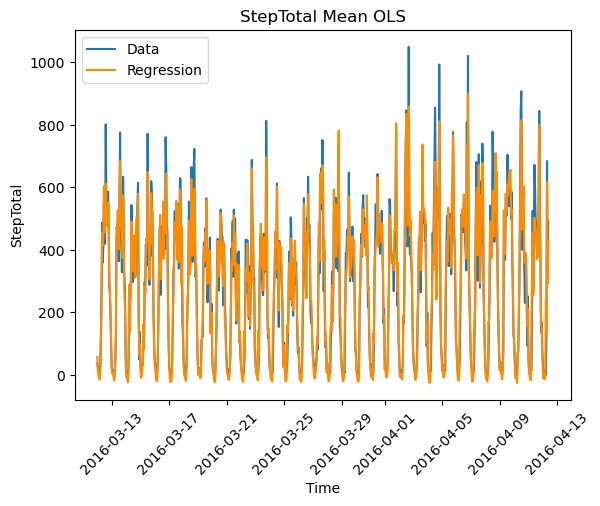

                            OLS Regression Results                            
Dep. Variable:              StepTotal   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                 1.397e+04
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:35:33   Log-Likelihood:                -4020.9
No. Observations:                 754   AIC:                             8046.
Df Residuals:                     752   BIC:                             8055.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -28.9007      3.234     -8.

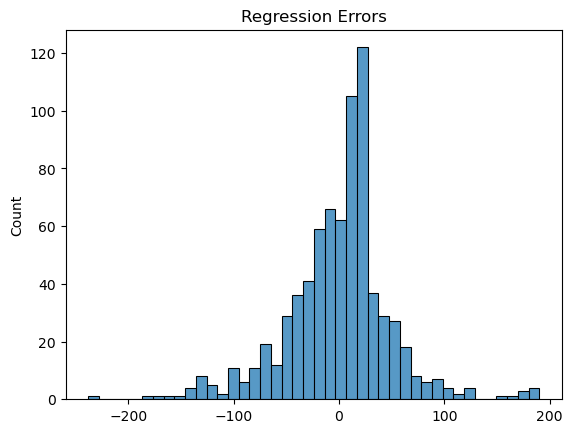

In [17]:
y = cis_means['StepTotal']
X = cis_means[['TotalIntensity']]
X = sm.add_constant(X)
plot_linear_regression(X, y, "StepTotal Mean OLS")

## Means STL

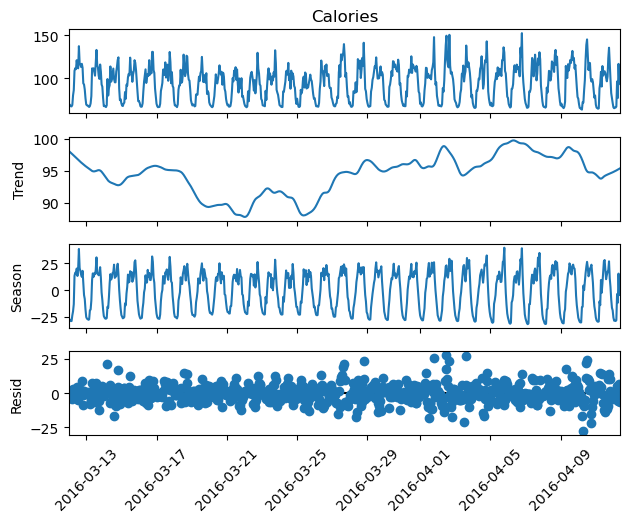

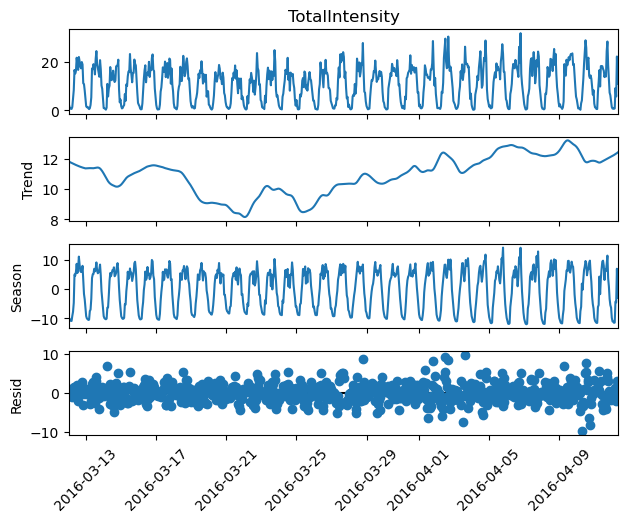

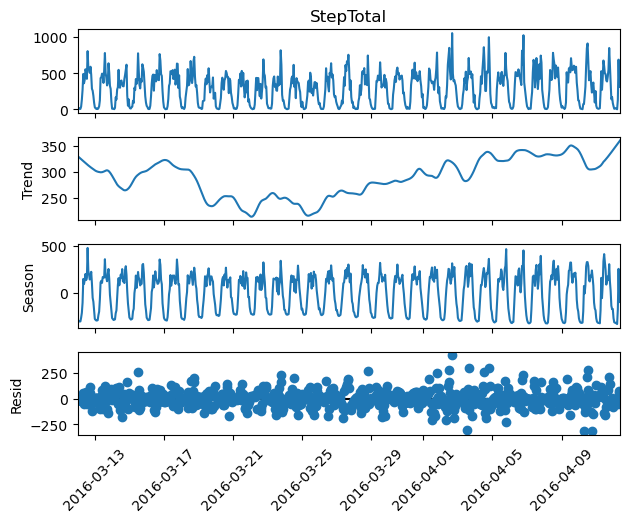

In [16]:
for var in cis_means:
    stl = STL(cis_means[var], period=24)
    res = stl.fit()
    fig = res.plot()
    plt.xticks(rotation=45)
    plt.show()

# Heart Rates

## Data

In [19]:
hr_df = pd.read_sql("""
                    SELECT Time, AVG(value) AS value
                    FROM heart_rate
                    GROUP BY Time
                    """, conn)
hr_df['Time'] = pd.to_datetime(hr_df['Time'], format=DATE_FMT)
dt = hr_df['Time'].dt
hr_df['Time'] = hr_df['Time'] - pd.to_timedelta(dt.minute, unit='minute') - pd.to_timedelta(dt.second, unit='second')
hr_stats = hr_df.groupby('Time')['value'].describe()
hr_stats

,count,mean,std,min,25%,50%,75%,max
Time,,,,,,,,
2016-03-29 00:00:00,325.0,69.252308,4.343759,59.0,67.0,69.000000,70.0,89.0
2016-03-29 01:00:00,342.0,65.982456,4.222511,59.0,63.0,65.000000,68.0,78.0
2016-03-29 02:00:00,320.0,67.343750,2.278554,60.0,66.0,67.000000,69.0,77.0
2016-03-29 03:00:00,332.0,62.750000,3.790691,56.0,61.0,62.000000,64.0,87.0
2016-03-29 04:00:00,307.0,60.514658,2.680530,55.0,59.0,60.000000,62.0,71.0
...,...,...,...,...,...,...,...,...
2016-04-12 07:00:00,1067.0,77.982722,11.104975,54.0,70.0,78.000000,85.0,128.0
2016-04-12 08:00:00,1150.0,69.247652,14.405269,47.0,57.0,66.416667,79.0,124.0
2016-04-12 09:00:00,1438.0,92.383391,23.668941,50.0,70.0,92.666667,114.0,134.0


## Stat Plot

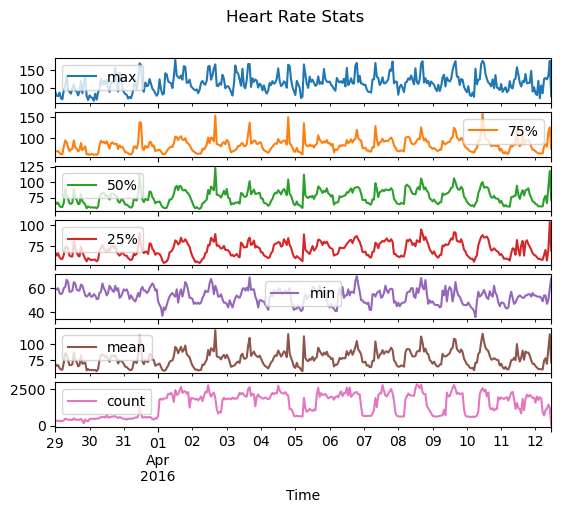

In [31]:
hr_stats.drop(columns=['std']).loc[:,::-1].plot(subplots=True, sharex=True)
plt.suptitle("Heart Rate Stats")
plt.show()

## Mean STL

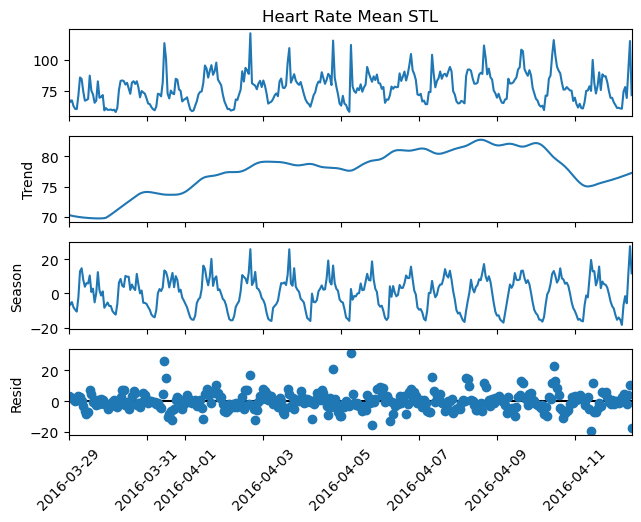

In [35]:
stl = STL(hr_stats['mean'].rename("Heart Rate Mean STL"), period=24)
res = stl.fit()
fig = res.plot()
plt.xticks(rotation=45)
plt.show()

# Sleep

## Data

In [44]:
minute_sleep = pd.read_sql("SELECT * from minute_sleep", conn)
minute_sleep[['Id', 'logId']] = minute_sleep[['Id', 'logId']].astype(int).astype(str)
minute_sleep['date'] = pd.to_datetime(minute_sleep['date'], format=DATE_FMT)
dt = minute_sleep['date'].dt
minute_sleep['Time'] = minute_sleep['date'] - pd.to_timedelta(dt.minute, unit='minute') - pd.to_timedelta(dt.second, unit='second')
minute_sleep['Duration'] = 1
sleep_df = minute_sleep.groupby(['Id', 'Time'])['Duration'].sum()
sleep_stats = sleep_df.reset_index().groupby('Time')['Duration'].describe()
sleep_stats

,count,mean,std,min,25%,50%,75%,max
Time,,,,,,,,
2016-03-11 21:00:00,3.0,24.666667,18.876794,4.0,16.5,29.0,35.0,41.0
2016-03-11 22:00:00,7.0,42.142857,20.497387,15.0,24.0,52.0,60.0,60.0
2016-03-11 23:00:00,10.0,50.400000,16.139668,17.0,42.0,60.0,60.0,60.0
2016-03-12 00:00:00,11.0,56.727273,10.854408,24.0,60.0,60.0,60.0,60.0
2016-03-12 01:00:00,11.0,60.000000,0.000000,60.0,60.0,60.0,60.0,60.0
...,...,...,...,...,...,...,...,...
2016-04-12 04:00:00,7.0,53.571429,17.008401,15.0,60.0,60.0,60.0,60.0
2016-04-12 05:00:00,6.0,59.000000,2.449490,54.0,60.0,60.0,60.0,60.0
2016-04-12 06:00:00,5.0,42.400000,22.512219,4.0,42.0,50.0,56.0,60.0


## Stat Plot

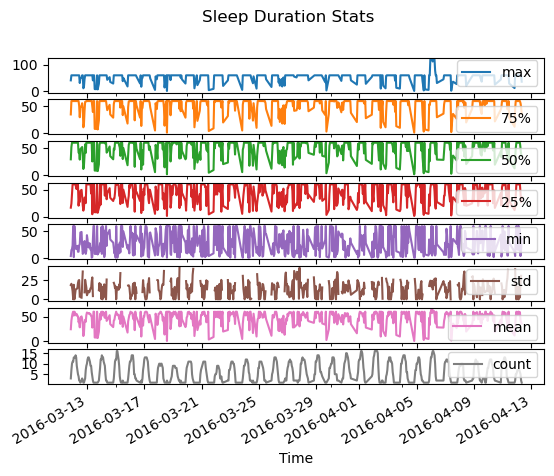

In [46]:
sleep_stats.loc[:,::-1].drop(columns=['std']).plot(subplots=True, sharex=True)
plt.suptitle("Sleep Duration Stats")
plt.show()

## Mean STL

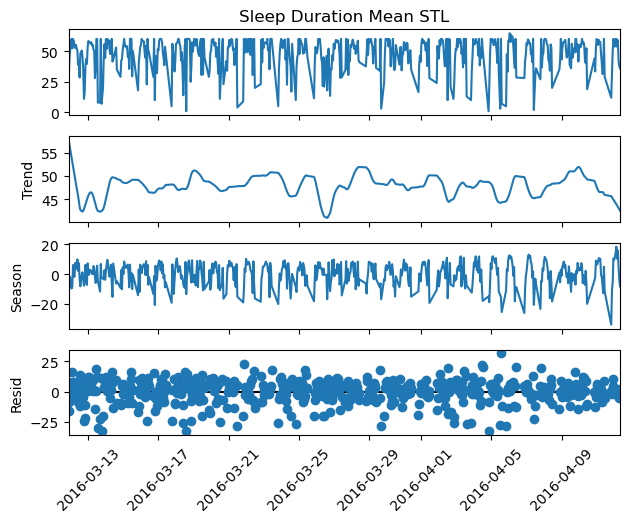

In [68]:
plot_stl(sleep_stats['mean'], period=16, title="Sleep Duration Mean STL")

# Combined Means

## Data

In [112]:
aligned_data = cis_means[['TotalIntensity']].join(sleep_stats[['mean']].rename(columns={'mean': 'Sleep'}), how='left')
aligned_data['Sleep'] = aligned_data['Sleep'].fillna(0)  # Pad missing sleep hours with 0
aligned_data = aligned_data.join(hr_stats[['mean']].rename(columns={'mean': 'HeartRate'}), how='inner')
aligned_data

,TotalIntensity,Sleep,HeartRate
Time,,,
2016-03-29 00:00:00,1.696970,60.000000,69.252308
2016-03-29 01:00:00,0.909091,56.916667,65.982456
2016-03-29 02:00:00,0.303030,58.714286,67.343750
2016-03-29 03:00:00,0.484848,60.000000,62.750000
2016-03-29 04:00:00,0.606061,56.857143,60.514658
...,...,...,...
2016-04-12 05:00:00,9.166667,59.000000,60.667119
2016-04-12 06:00:00,5.647059,42.400000,74.248266
2016-04-12 07:00:00,22.266667,38.000000,77.982722


## Cross-Correlation Analysis

In [121]:
def plot_ccf(df, y, lags):
    # Compute cross-correlations for each variable with sleep
    ccf_results = {}
    for col in df.drop(columns=y):
        ccf = smt.ccf(df[y], df[col], adjusted=False)
        ccf_results[col] = ccf[:len(lags)]  # Take relevant lags

    # Plot
    plt.figure(figsize=(10, 6))
    for col, ccf_vals in ccf_results.items():
        plt.plot(lags, ccf_vals, label=col)
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel('Lag (hours)')
    plt.ylabel('Cross-Correlation')
    plt.title(f'Cross-Correlation with {y}')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Identify significant peaks (focus on lags -12 to 12 to avoid edge artifacts)
    significant_lags = [lag for lag in lags if abs(lag) <= 12]
    for col in ccf_results:
        max_corr = max(ccf_results[col][i] for i, lag in enumerate(lags) if lag in significant_lags)
        max_lag = lags[ccf_results[col].tolist().index(max_corr)]
        print(f"{col}: Peak correlation {max_corr:.3f} at lag {max_lag}")

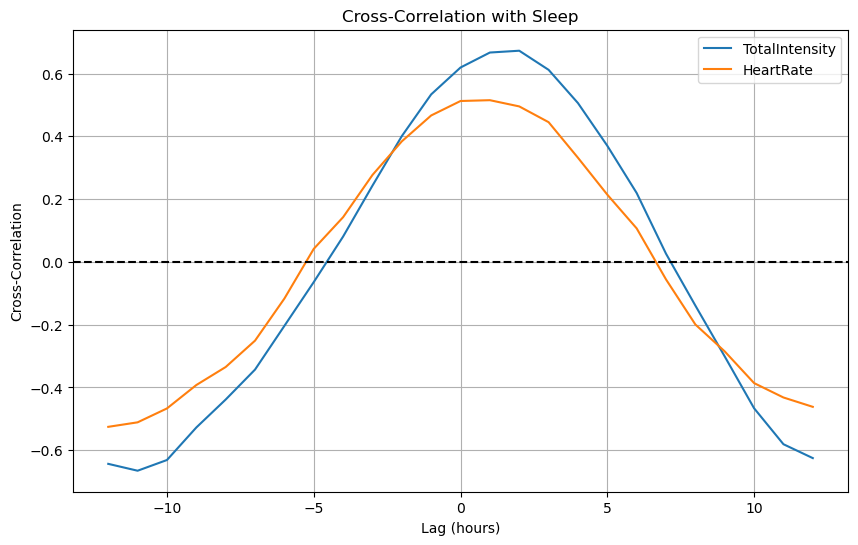

TotalIntensity: Peak correlation 0.673 at lag 2
HeartRate: Peak correlation 0.515 at lag 1


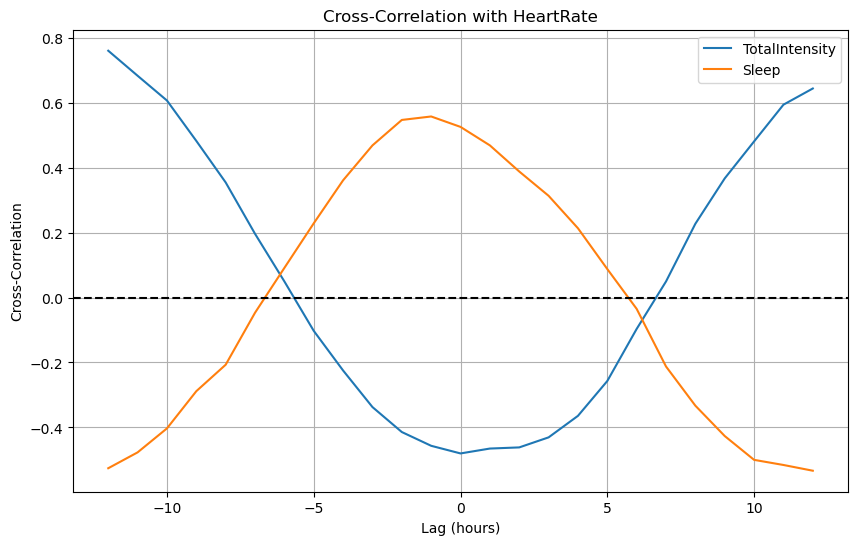

TotalIntensity: Peak correlation 0.760 at lag -12
Sleep: Peak correlation 0.557 at lag -1


In [122]:
LAG = 12
for y in ['Sleep', 'HeartRate']:
    plot_ccf(aligned_data, y, range(-LAG, LAG + 1))

## OLS

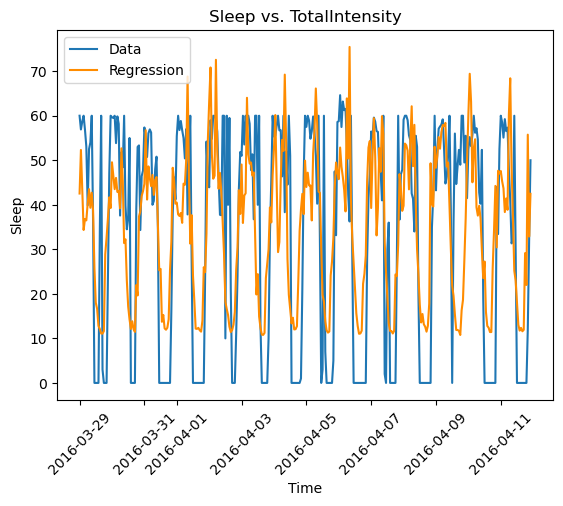

                            OLS Regression Results                            
Dep. Variable:                  Sleep   R-squared:                       0.438
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     259.0
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           1.62e-43
Time:                        17:38:55   Log-Likelihood:                -1449.0
No. Observations:                 335   AIC:                             2902.
Df Residuals:                     333   BIC:                             2910.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             10.5295      1.800      5.

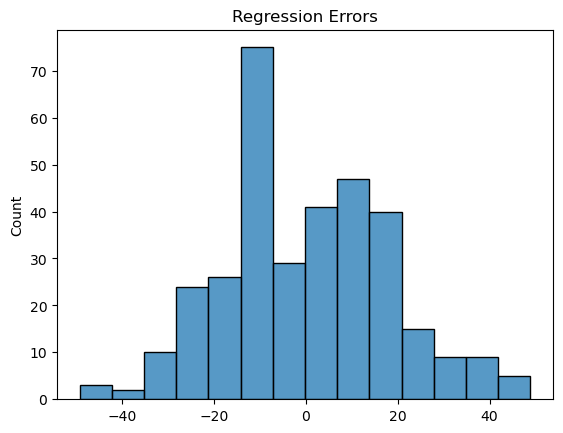

In [135]:
# Shift activity by the optimal lag (e.g., -6)
lag = -11  # Adjust based on your peak
X = aligned_data[['TotalIntensity']].shift(lag).dropna()
y = aligned_data['Sleep'][X.index]
X = sm.add_constant(X)
plot_linear_regression(X, y, title="Sleep vs. TotalIntensity")

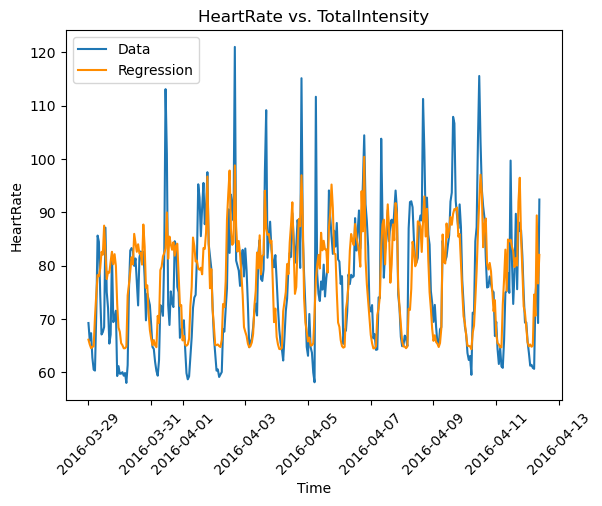

                            OLS Regression Results                            
Dep. Variable:              HeartRate   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     470.1
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           2.51e-66
Time:                        17:35:13   Log-Likelihood:                -1196.6
No. Observations:                 346   AIC:                             2397.
Df Residuals:                     344   BIC:                             2405.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             64.2095      0.737     87.

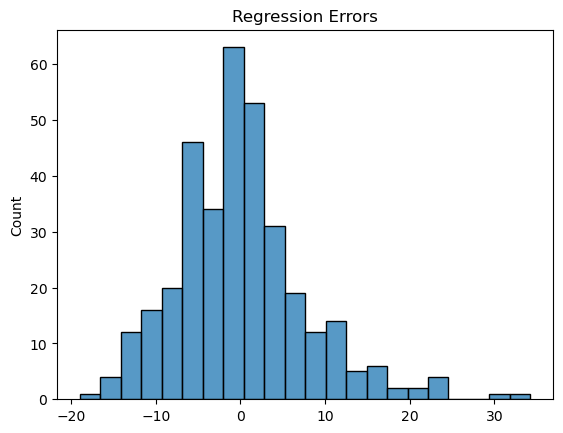

In [129]:
# Shift activity by the optimal lag (e.g., -6)
lag = 0  # Adjust based on your peak
X = aligned_data[['TotalIntensity']].shift(lag).dropna()
y = aligned_data['HeartRate'][X.index]
X = sm.add_constant(X)
plot_linear_regression(X, y, title="HeartRate vs. TotalIntensity")